In [20]:
import numpy as np
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
import scipy.linalg as linalg_d
import importlib
import os
import time
import copy as copy
import QO_trunc_functions as QOtrunc
import density_matrix_extension as dme
import computing_constructions as cc
import matplotlib.pyplot as plt

In [21]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

In [22]:
'''
# this cell has been commented out because it takes over 24 hours to evaluate, the resulting data is saved as 'vary_gammat_int_data_ideal_drive.npy' and can be loaded for plotting
MIS_adj=np.zeros([3,3])
MIS_adj[0,1]=1
MIS_adj[1,2]=1
MIS_adj=MIS_adj+MIS_adj.T
num_cycle_loop=200
tot_angle=20*np.pi
num_gammat=10
gammat_data={}
gammat_data['gammat_arr']=np.linspace(np.pi/(4*np.sqrt(2)),np.pi/(2*np.sqrt(2)),num_gammat)
gammat_data['probs_arr']=np.nan*np.ones([num_gammat,num_cycle_loop,8])
gammat_data['num_cycle_arr']=np.array(np.around(np.logspace(1,5+np.log10(2),num_cycle_loop)),dtype=int)
gammat_data['svn_arr']=np.nan*np.ones([num_gammat,num_cycle_loop])
stopping_threshold=0.99
supOp_drive={}
supOp_drive['mult_before']=np.eye(4)
supOp_drive['mult_after']=np.eye(4)
a1=QOtrunc.make_annihiltion_Op(n_trunc=1)
supOp_drive['supOp_gen']=dme.build_coherent_supOp(a1+a1.conj().T).todense()
for i_gammat in range(num_gammat): #range(num_gammat-1,-1,-1):
    for i_cycle in range(num_cycle_loop):
        #print(i_cycle)
        #print(i_gammat)
        num_cycle=gammat_data['num_cycle_arr'][i_cycle]
        (phase_sched,driving_sched)=cc.optimal_phase_and_disp_schedule_norm(num_cycle)
        interaction_supOp=cc.two_mode_0_1_HOM_nl_apply(gamma=gammat_data['gammat_arr'][i_gammat])
        phase_schedule=(tot_angle/num_cycle)*phase_sched
        driving_schedule=(tot_angle/num_cycle)*driving_sched
        (rho_vec,intermediate_data)=cc.optical_anneal_wmis(supOp_drive,phase_schedule,MIS_adj,driving_schedule=driving_schedule,driving='before',interaction_supOp=interaction_supOp)
        gammat_data['probs_arr'][i_gammat,i_cycle,:]=np.real(np.diag(dme.vectorized_rho_to_matrix_rho(rho_vec)))
        gammat_data['svn_arr'][i_gammat,i_cycle]=dme.calculate_von_Neumann_entropy(rho_vec)
        #print(gammat_data['probs_arr'][i_gammat,i_cycle,5])
        if gammat_data['probs_arr'][i_gammat,i_cycle,5]>stopping_threshold:
            break
    plt.semilogx(gammat_data['num_cycle_arr'],gammat_data['probs_arr'][i_gammat,:,:])
    plt.show()
    plt.semilogx(gammat_data['num_cycle_arr'],gammat_data['svn_arr'].T)
    plt.show()
#np.save('vary_gammat_int_data_ideal_drive.npy',gammat_data)
'''        

"\n# this cell has been commented out because it takes over 24 hours to evaluate, the resulting data is saved as 'vary_gammat_int_data_ideal_drive.npy' and can be loaded for plotting\nMIS_adj=np.zeros([3,3])\nMIS_adj[0,1]=1\nMIS_adj[1,2]=1\nMIS_adj=MIS_adj+MIS_adj.T\nnum_cycle_loop=200\ntot_angle=20*np.pi\nnum_gammat=10\ngammat_data={}\ngammat_data['gammat_arr']=np.linspace(np.pi/(4*np.sqrt(2)),np.pi/(2*np.sqrt(2)),num_gammat)\ngammat_data['probs_arr']=np.nan*np.ones([num_gammat,num_cycle_loop,8])\ngammat_data['num_cycle_arr']=np.array(np.around(np.logspace(1,5+np.log10(2),num_cycle_loop)),dtype=int)\ngammat_data['svn_arr']=np.nan*np.ones([num_gammat,num_cycle_loop])\nstopping_threshold=0.99\nsupOp_drive={}\nsupOp_drive['mult_before']=np.eye(4)\nsupOp_drive['mult_after']=np.eye(4)\na1=QOtrunc.make_annihiltion_Op(n_trunc=1)\nsupOp_drive['supOp_gen']=dme.build_coherent_supOp(a1+a1.conj().T).todense()\nfor i_gammat in range(num_gammat): #range(num_gammat-1,-1,-1):\n    for i_cycle in rang

In [23]:
gammat_data=np.load('vary_gammat_int_data_ideal_drive.npy',allow_pickle=True)[()]

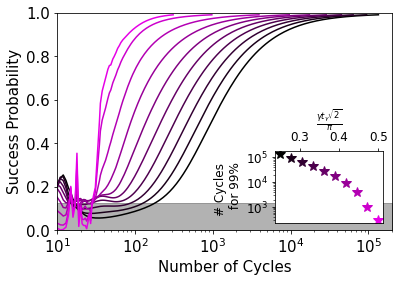

In [24]:
fig=plt.figure()
ax0=plt.gca()
fig.add_axes([0.63,0.15,0.25,0.25])
ax1=plt.gca()
for i_color in range(10):
    line_color=[i_color/10,0,i_color/10]
    ax0.semilogx(gammat_data['num_cycle_arr'],gammat_data['probs_arr'][i_color,:,5],color=line_color)
    max_index=sum(1-np.isnan(gammat_data['probs_arr'][i_color,:,5]))-1
    thresh_99_value=gammat_data['num_cycle_arr'][max_index]
    ax1.semilogy(gammat_data['gammat_arr'][i_color]*np.sqrt(2)/np.pi,gammat_data['num_cycle_arr'][max_index],'*',markersize=10,color=line_color)
plt.sca(ax0)
plt.ylim(0,1)
plt.xlim(10,2*10**5)
plt.xlabel('Number of Cycles',fontsize=15)
plt.ylabel('Success Probability',fontsize=15)
plt.fill_between([10,2*10**5],[0,0],[1/8,1/8],color=[0,0,0,0.3])
plt.sca(ax1)
plt.xlabel(r'$\frac{\gamma t_\gamma \sqrt{2}}{\pi}$',fontsize=12)
ax1.xaxis.set_label_position('top') 
plt.ylabel('# Cycles \n for 99%',fontsize=12)
ax0.tick_params(labelsize=15)
ax1.tick_params(labelsize=12)
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.savefig('figures/interaction_coherence_scaling.pdf',bbox_inches='tight')
plt.show()

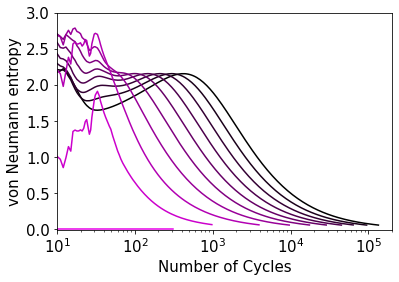

In [25]:
ax0=plt.gca()
for i_color in range(10):
    line_color=[i_color/10,0,i_color/10]
    ax0.semilogx(gammat_data['num_cycle_arr'],gammat_data['svn_arr'][i_color,:],color=line_color)
plt.xlim(10,2*10**5)
plt.ylim(-0.01,3)
ax0.tick_params(labelsize=15)
plt.xlabel('Number of Cycles',fontsize=15)
plt.ylabel('von Neumann entropy',fontsize=15)
plt.savefig('figures/interaction_coherence_entropy.pdf',bbox_inches='tight')
plt.show()

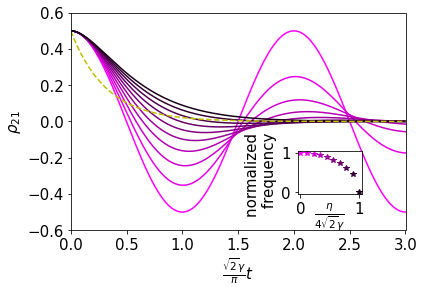

In [26]:
rho_init=np.zeros([3,3])
rho_init[1,1]=0.5
rho_init[1,2]=0.5
rho_init[2,1]=0.5
rho_init[2,2]=0.5
calculate_func=lambda x: np.real(dme.convert_rho_to_matrix_idem(x)[1,2])
eta_pump_loss_arr=np.linspace(0,4*np.sqrt(2),10)
t_max=3*np.pi/np.sqrt(2)
nt=200
fig=plt.figure()
ax0=plt.gca()
fig.add_axes([0.65,0.25,0.15,0.15])
ax1=plt.gca()
for i_eta in range(len(eta_pump_loss_arr)):
    line_color=[1-i_eta/10,0,1-i_eta/10]
    coh_arr=cc.coherent_driving_time_series(1,0,calculate_func,rho_init=rho_init,eta_pump_loss=eta_pump_loss_arr[i_eta],t_max=t_max,nt=nt)
    ax0.plot(np.linspace(0,t_max,nt)*np.sqrt(2)/np.pi,coh_arr,color=line_color)
    ax1.plot(eta_pump_loss_arr[i_eta]/(4*np.sqrt(2)),np.sqrt(abs(32-eta_pump_loss_arr[i_eta]**2))/(4*np.sqrt(2)),'*',color=line_color)
plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel(r'$\frac{\eta}{4\sqrt{2}\gamma}$',fontsize=15,labelpad=-15)
plt.ylabel('normalized \n frequency',fontsize=15)
plt.sca(ax0)
tpa_arr=cc.tpa_driving_time_series(np.sqrt(2),0,calculate_func=calculate_func,rho_init=rho_init,t_max=t_max,nt=nt)
plt.plot(np.linspace(0,t_max,nt)*np.sqrt(2)/np.pi,tpa_arr,'--',color=[0.75,0.75,0])
ax0=plt.gca()
plt.xlim(0,3)
ax0.tick_params(labelsize=15)
plt.ylim(-0.6,0.6)
plt.xlabel(r'$\frac{\sqrt{2}\gamma}{\pi}t$',fontsize=15)
plt.ylabel(r'$\rho_{21}$',fontsize=15)
plt.savefig('figures/rho_12_lossy_sfg.pdf',bbox_inches='tight')
plt.show()


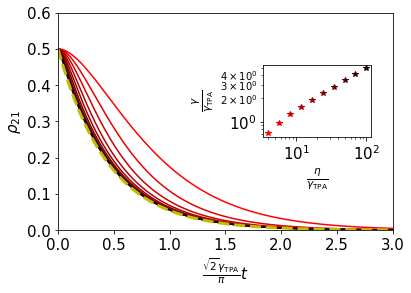

In [27]:
rho_init=np.zeros([3,3])
rho_init[1,1]=0.5
rho_init[1,2]=0.5
rho_init[2,1]=0.5
rho_init[2,2]=0.5
calculate_func=lambda x: np.real(dme.convert_rho_to_matrix_idem(x)[1,2])
#eta_crit=(np.sqrt(2)+np.sqrt(2+8/np.sqrt(2)))**2
eta_pump_loss_arr=np.logspace(np.log10(4),2,10)
t_max=3*np.pi/np.sqrt(2)
nt=200
fig=plt.figure()
ax0=plt.gca()
fig.add_axes([0.6,0.45,0.25,0.25])
ax1=plt.gca()
for i_eta in range(len(eta_pump_loss_arr)):
    line_color=[1-i_eta/10,0,0]
    gamma=np.sqrt(0.5)*np.sqrt((eta_pump_loss_arr[i_eta]**2)/16-(eta_pump_loss_arr[i_eta]/4-1)**2)
    #coh_arr=cc.coherent_driving_time_series(1+np.sqrt(eta_pump_loss_arr[i_eta])/2,0,calculate_func,rho_init=rho_init,eta_pump_loss=eta_pump_loss_arr[i_eta],t_max=t_max,nt=nt)
    coh_arr=cc.coherent_driving_time_series(gamma,0,calculate_func,rho_init=rho_init,eta_pump_loss=eta_pump_loss_arr[i_eta],t_max=t_max,nt=nt)
    ax0.plot(np.linspace(0,t_max,nt)*np.sqrt(2)/np.pi,coh_arr,color=line_color)
    ax1.loglog(eta_pump_loss_arr[i_eta],gamma,'*',color=line_color)
plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel(r'$\frac{\eta}{\gamma_\mathrm{TPA}}$',fontsize=15)
plt.ylabel(r'$\frac{\gamma}{\gamma_\mathrm{TPA}}$',fontsize=15)
plt.sca(ax0)
tpa_arr=cc.tpa_driving_time_series(1,0,calculate_func=calculate_func,rho_init=rho_init,t_max=t_max,nt=nt)
plt.plot(np.linspace(0,t_max,nt)*np.sqrt(2)/np.pi,tpa_arr,'--',color=[0.75,0.75,0],linewidth=3)
ax0=plt.gca()
plt.xlim(0,3)
ax0.tick_params(labelsize=15)
plt.ylim(0,0.6)
plt.xlabel(r'$\frac{\sqrt{2}\gamma_\mathrm{TPA}}{\pi}t$',fontsize=15)
plt.ylabel(r'$\rho_{21}$',fontsize=15)
plt.savefig('figures/rho_12_markov_approach.pdf',bbox_inches='tight')
plt.show()

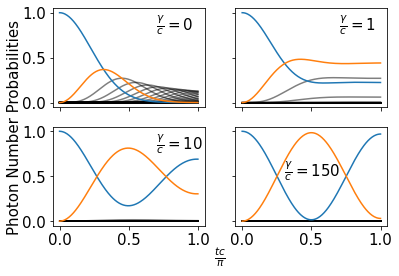

In [28]:
(fig, axs)=plt.subplots(2,2,sharey=True,sharex=True)
mode_count=30
#mode_count=5
calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(x))
t_max=np.pi
nt=200
ax0=plt.subplot(2,2,1)
tpa_list=cc.tpa_driving_time_series(0,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax0.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,2:],color='k',alpha=0.5)
ax0.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,0])
ax0.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,1])
ax0.text(0.7,0.8,r'$\frac{\gamma}{c}=0$',fontsize=15)
ax0.tick_params(labelsize=15)
plt.ylabel('Photon Number Probabilities',fontsize=15)
axs[0,0].yaxis.set_label_coords(-0.2,-0.2) # needs to be after the label is added
ax1=plt.subplot(2,2,2)
tpa_list=cc.tpa_driving_time_series(1,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax1.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,2:],color='k',alpha=0.5)
ax1.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,0])
ax1.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,1])
ax1.tick_params(labelsize=15)
ax1.text(0.7,0.8,r'$\frac{\gamma}{c}=1$',fontsize=15)
ax2=plt.subplot(2,2,3)
tpa_list=cc.tpa_driving_time_series(10,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax2.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,2:],color='k',alpha=0.5)
ax2.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,0])
ax2.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,1])
ax2.tick_params(labelsize=15)
ax2.text(0.7,0.8,r'$\frac{\gamma}{c}=10$',fontsize=15)
ax3=plt.subplot(2,2,4)
tpa_list=cc.tpa_driving_time_series(150,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax3.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,2:],color='k',alpha=0.5)
ax3.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,0])
ax3.plot(np.linspace(0,1,nt),np.array(tpa_list)[:,1])
ax3.text(0.3,0.5,r'$\frac{\gamma}{c}=150$',fontsize=15)
ax3.tick_params(labelsize=15)
plt.xlabel(r'$\frac{tc}{\pi}$',fontsize=15)
ax3.xaxis.set_label_coords(-0.1,-0.2)
plt.savefig('figures/Zeno_onset_TPA.pdf',bbox_inches='tight')
plt.show()

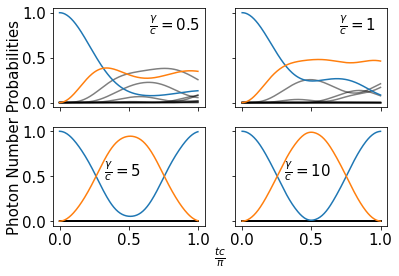

In [29]:
(fig, axs)=plt.subplots(2,2,sharey=True,sharex=True)
mode_count=10
#mode_count=5
traceout_mat_rho_vec=dme.make_partial_trace_supOp_space_sizes(int(np.floor((mode_count)/2))+1,mode_count+1,1)
calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(traceout_mat_rho_vec@x))
t_max=np.pi
nt=200
ax0=plt.subplot(2,2,1)
sfg_list=cc.coherent_driving_time_series(0.5,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax0.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,2:],color='k',alpha=0.5)
ax0.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,0])
ax0.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,1])
ax0.text(0.65,0.8,r'$\frac{\gamma}{c}=0.5$',fontsize=15)
ax0.tick_params(labelsize=15)
plt.ylabel('Photon Number Probabilities',fontsize=15)
axs[0,0].yaxis.set_label_coords(-0.2,-0.2) # needs to be after the label is added
ax1=plt.subplot(2,2,2)
sfg_list=cc.coherent_driving_time_series(1,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax1.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,2:],color='k',alpha=0.5)
ax1.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,0])
ax1.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,1])
ax1.tick_params(labelsize=15)
ax1.text(0.7,0.8,r'$\frac{\gamma}{c}=1$',fontsize=15)
ax2=plt.subplot(2,2,3)
sfg_list=cc.coherent_driving_time_series(5,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax2.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,2:],color='k',alpha=0.5)
ax2.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,0])
ax2.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,1])
ax2.tick_params(labelsize=15)
ax2.text(0.32,0.5,r'$\frac{\gamma}{c}=5$',fontsize=15)
ax3=plt.subplot(2,2,4)
sfg_list=cc.coherent_driving_time_series(10,1,calculate_func=calculate_func,rho_init=mode_count,t_max=t_max,nt=nt)
ax3.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,2:],color='k',alpha=0.5)
ax3.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,0])
ax3.plot(np.linspace(0,1,nt),np.array(sfg_list)[:,1])
ax3.text(0.3,0.5,r'$\frac{\gamma}{c}=10$',fontsize=15)
ax3.tick_params(labelsize=15)
plt.xlabel(r'$\frac{t c}{\pi}$',fontsize=15)
ax3.xaxis.set_label_coords(-0.1,-0.2)
plt.savefig('figures/Zeno_onset_SFG.pdf',bbox_inches='tight')
plt.show()

In [30]:
'''
# this cell is commented because it takes about an hour to run
n_gamma=200
n_eta_ratio=10
eta_gamma_data_sfg_drive={}
eta_gamma_data_sfg_drive['gamma_arr']=np.logspace(-2,np.log10(500),n_gamma)
eta_gamma_data_sfg_drive['one_prob_arr']=np.nan*np.ones([n_gamma,n_eta_ratio])
eta_gamma_data_sfg_drive['eta_ratio_arr']=np.linspace(0,4*np.sqrt(2),n_eta_ratio)
eta_gamma_data_sfg_drive['one_prob_arr_TPA']=np.nan*np.ones(n_gamma)
calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(x))[1]
mode_count=np.nan
for i_gamma in range(n_gamma):
        gamma=eta_gamma_data_sfg_drive['gamma_arr'][i_gamma]
        mode_count_old=mode_count
        if gamma<10:
            mode_count=10
        else:
            mode_count=5
        rho_diag_val=cc.tpa_driving_time_series(gamma,1,calculate_func=calculate_func,rho_init=mode_count,t_max=np.pi/2,nt=1)
        eta_gamma_data_sfg_drive['one_prob_arr_TPA'][i_gamma]=np.real(rho_diag_val)
        if np.real(rho_diag_val)> 0.99:
            break # break out of for loop if we have exceeded 99% threshold
start_time=time.time()
mode_count_old=np.nan
for i_eta_ratio in range(n_eta_ratio):
    eta_ratio=eta_gamma_data_sfg_drive['eta_ratio_arr'][i_eta_ratio]
    for i_gamma in range(n_gamma):
        gamma=eta_gamma_data_sfg_drive['gamma_arr'][i_gamma]
        mode_count_old=mode_count
        if gamma<10:
            mode_count=10
        else:
            mode_count=5
        if not mode_count_old==mode_count:
            traceout_mat_rho_vec=dme.make_partial_trace_supOp_space_sizes(int(np.floor((mode_count)/2))+1,mode_count+1,1)
        calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(traceout_mat_rho_vec@x))[1]
        rho_diag_val=cc.coherent_driving_time_series(gamma,1,calculate_func=calculate_func,rho_init=mode_count,eta_pump_loss=eta_ratio*gamma,t_max=np.pi/2,nt=1)
        eta_gamma_data_sfg_drive['one_prob_arr'][i_gamma,i_eta_ratio]=np.real(rho_diag_val)
        if np.real(rho_diag_val)> 0.99:
            break # break out of for loop if we have exceeded 99% threshold
        #print(i_gamma)
        #print(i_eta_ratio)
        etime=time.time()-start_time
        #print(etime)
np.save('vary_eta_gamma_data_sfg_drive.npy',eta_gamma_data_sfg_drive)
'''

"\n# this cell is commented because it takes about an hour to run\nn_gamma=200\nn_eta_ratio=10\neta_gamma_data_sfg_drive={}\neta_gamma_data_sfg_drive['gamma_arr']=np.logspace(-2,np.log10(500),n_gamma)\neta_gamma_data_sfg_drive['one_prob_arr']=np.nan*np.ones([n_gamma,n_eta_ratio])\neta_gamma_data_sfg_drive['eta_ratio_arr']=np.linspace(0,4*np.sqrt(2),n_eta_ratio)\neta_gamma_data_sfg_drive['one_prob_arr_TPA']=np.nan*np.ones(n_gamma)\ncalculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(x))[1]\nmode_count=np.nan\nfor i_gamma in range(n_gamma):\n        gamma=eta_gamma_data_sfg_drive['gamma_arr'][i_gamma]\n        mode_count_old=mode_count\n        if gamma<10:\n            mode_count=10\n        else:\n            mode_count=5\n        rho_diag_val=cc.tpa_driving_time_series(gamma,1,calculate_func=calculate_func,rho_init=mode_count,t_max=np.pi/2,nt=1)\n        eta_gamma_data_sfg_drive['one_prob_arr_TPA'][i_gamma]=np.real(rho_diag_val)\n        if np.real(rho_diag_val)> 0.99:\n

In [31]:
eta_gamma_data_sfg_drive_data=np.load('vary_eta_gamma_data_sfg_drive.npy',allow_pickle=True)[()]

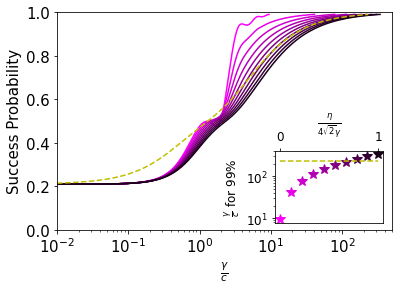

In [32]:
fig=plt.figure()
ax0=plt.gca()
fig.add_axes([0.63,0.15,0.25,0.25])
ax1=plt.gca()
for i_color in range(10):
    line_color=[1-i_color/10,0,1-i_color/10]
    ax0.semilogx(eta_gamma_data_sfg_drive_data['gamma_arr'],eta_gamma_data_sfg_drive_data['one_prob_arr'][:,i_color],color=line_color)
    max_index=sum(1-np.isnan(eta_gamma_data_sfg_drive_data['one_prob_arr'][:,i_color]))-1
    thresh_99_value=eta_gamma_data_sfg_drive_data['gamma_arr'][max_index]
    ax1.semilogy(eta_gamma_data_sfg_drive_data['eta_ratio_arr'][i_color]/(4*np.sqrt(2)),eta_gamma_data_sfg_drive_data['gamma_arr'][max_index],'*',markersize=10,color=line_color)
max_index_TPA=sum(1-np.isnan(eta_gamma_data_sfg_drive_data['one_prob_arr_TPA']))-1
ax1.semilogy([0,1],[eta_gamma_data_sfg_drive_data['gamma_arr'][max_index_TPA]]*2,'--',markersize=10,color=[0.75,0.75,0])
plt.sca(ax0)
plt.semilogx(eta_gamma_data_sfg_drive_data['gamma_arr'],eta_gamma_data_sfg_drive_data['one_prob_arr_TPA'],'--',color=[0.75,0.75,0])
plt.ylim(0,1)
plt.xlim(0.01,500)
plt.xlabel(r'$\frac{\gamma}{c}$',fontsize=15)
plt.ylabel('Success Probability',fontsize=15)
plt.sca(ax1)
plt.xlabel(r'$\frac{\eta}{4\sqrt{2}\gamma}$',fontsize=12)
ax1.xaxis.set_label_position('top') 
plt.ylabel(r'$\frac{\gamma}{c}$ for 99%',fontsize=12)
ax0.tick_params(labelsize=15)
ax1.tick_params(labelsize=12)
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.savefig('figures/incohere_cohere_drive.pdf',bbox_inches='tight')
plt.show()

In [33]:
'''
# this cell is commented because it takes nearly 6 hours to run
n_gamma=200
n_eta_ratio=10
eta_gamma_data_markov_approach={}
eta_gamma_data_markov_approach['gamma_TPA_arr']=np.logspace(-2,np.log10(500),n_gamma)
eta_gamma_data_markov_approach['one_prob_arr']=np.nan*np.ones([n_gamma,n_eta_ratio])
eta_gamma_data_markov_approach['eta_ratio_arr']=np.logspace(0,2,n_eta_ratio)
eta_gamma_data_markov_approach['one_prob_arr_TPA']=np.nan*np.ones(n_gamma)
calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(x))[1]
eta_gamma_data_markov_approach['gamma_TPA_99_arr']=np.zeros(n_eta_ratio)
mode_count=np.nan
for i_gamma in range(n_gamma):
        gamma_TPA=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma]
        mode_count_old=mode_count
        if gamma_TPA<10:
            mode_count=10
        else:
            mode_count=5
        rho_diag_val=cc.tpa_driving_time_series(gamma_TPA,1,calculate_func=calculate_func,rho_init=mode_count,t_max=np.pi/2,nt=1)
        eta_gamma_data_markov_approach['one_prob_arr_TPA'][i_gamma]=np.real(rho_diag_val)
        if np.real(rho_diag_val)> 0.99:
            gamma_TPA_low=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma-1]
            gamma_TPA_high=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma]
            for i_bisect in range(n_bisect):
                gamma_TPA=(gamma_TPA_low+gamma_TPA_high)/2
                rho_diag_val=cc.tpa_driving_time_series(gamma_TPA,1,calculate_func=calculate_func,rho_init=mode_count,t_max=np.pi/2,nt=1)
                if np.real(rho_diag_val)> 0.99:
                    gamma_TPA_high=copy.copy(gamma_TPA)
                else:
                    gamma_TPA_low=copy.copy(gamma_TPA)
            eta_gamma_data_markov_approach['TPA_gamma_99']=(gamma_TPA_low+gamma_TPA_high)/2
            break # break out of for loop if we have exceeded 99% threshold
start_time=time.time()
mode_count_old=np.nan
n_bisect=10
for i_eta_ratio in range(n_eta_ratio):
    eta_ratio=eta_gamma_data_markov_approach['eta_ratio_arr'][i_eta_ratio]
    for i_gamma in range(n_gamma):
        gamma_TPA=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma]
        eta=4*eta_ratio*gamma_TPA
        gamma=np.sqrt(0.5)*np.sqrt((eta**2)/16-(eta/4-gamma_TPA)**2)
        mode_count_old=mode_count
        if gamma<10:
            mode_count=10
        else:
            mode_count=5
        if not mode_count_old==mode_count:
            traceout_mat_rho_vec=dme.make_partial_trace_supOp_space_sizes(int(np.floor((mode_count)/2))+1,mode_count+1,1)
        calculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(traceout_mat_rho_vec@x))[1]
        rho_diag_val=cc.coherent_driving_time_series(gamma,1,calculate_func=calculate_func,rho_init=mode_count,eta_pump_loss=eta,t_max=np.pi/2,nt=1)
        eta_gamma_data_markov_approach['one_prob_arr'][i_gamma,i_eta_ratio]=np.real(rho_diag_val)
        if np.real(rho_diag_val)> 0.99:
            gamma_TPA_low=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma-1]
            gamma_TPA_high=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma]
            for i_bisect in range(n_bisect):
                gamma_TPA=(gamma_TPA_low+gamma_TPA_high)/2
                eta=4*eta_ratio*gamma_TPA
                gamma=np.sqrt(0.5)*np.sqrt((eta**2)/16-(eta/4-gamma_TPA)**2)
                rho_diag_val=cc.coherent_driving_time_series(gamma,1,calculate_func=calculate_func,rho_init=mode_count,eta_pump_loss=eta,t_max=np.pi/2,nt=1)
                if np.real(rho_diag_val)> 0.99:
                    gamma_TPA_high=copy.copy(gamma_TPA)
                else:
                    gamma_TPA_low=copy.copy(gamma_TPA)
            eta_gamma_data_markov_approach['gamma_TPA_99_arr'][i_eta_ratio]=(gamma_TPA_low+gamma_TPA_high)/2
            break # break out of for loop if we have exceeded 99% threshold
#print(time.time()-start_time)
#np.save('vary_eta_gamma_data_markov_approach.npy',eta_gamma_data_markov_approach)
'''

"\n# this cell is commented because it takes nearly 6 hours to run\nn_gamma=200\nn_eta_ratio=10\neta_gamma_data_markov_approach={}\neta_gamma_data_markov_approach['gamma_TPA_arr']=np.logspace(-2,np.log10(500),n_gamma)\neta_gamma_data_markov_approach['one_prob_arr']=np.nan*np.ones([n_gamma,n_eta_ratio])\neta_gamma_data_markov_approach['eta_ratio_arr']=np.logspace(0,2,n_eta_ratio)\neta_gamma_data_markov_approach['one_prob_arr_TPA']=np.nan*np.ones(n_gamma)\ncalculate_func=lambda x: np.diag(dme.vectorized_rho_to_matrix_rho(x))[1]\neta_gamma_data_markov_approach['gamma_TPA_99_arr']=np.zeros(n_eta_ratio)\nmode_count=np.nan\nfor i_gamma in range(n_gamma):\n        gamma_TPA=eta_gamma_data_markov_approach['gamma_TPA_arr'][i_gamma]\n        mode_count_old=mode_count\n        if gamma_TPA<10:\n            mode_count=10\n        else:\n            mode_count=5\n        rho_diag_val=cc.tpa_driving_time_series(gamma_TPA,1,calculate_func=calculate_func,rho_init=mode_count,t_max=np.pi/2,nt=1)\n      

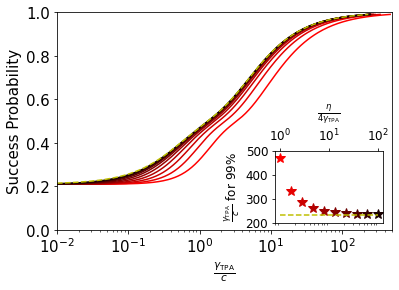

In [34]:
eta_gamma_data_markov_approach=np.load('vary_eta_gamma_data_markov_approach.npy',allow_pickle=True)[()]
fig=plt.figure()
ax0=plt.gca()
fig.add_axes([0.63,0.15,0.25,0.25])
ax1=plt.gca()
for i_color in range(10):
    line_color=[1-i_color/10,0,0]
    ax0.semilogx(eta_gamma_data_markov_approach['gamma_TPA_arr'],eta_gamma_data_markov_approach['one_prob_arr'][:,i_color],color=line_color)
    ax1.semilogx(eta_gamma_data_markov_approach['eta_ratio_arr'][i_color],eta_gamma_data_markov_approach['gamma_TPA_99_arr'][i_color],'*',markersize=10,color=line_color)
max_index_TPA=sum(1-np.isnan(eta_gamma_data_sfg_drive_data['one_prob_arr_TPA']))-1
ax1.semilogx([1,max(eta_gamma_data_markov_approach['eta_ratio_arr'])],[eta_gamma_data_markov_approach['TPA_gamma_99']]*2,'--',markersize=10,color=[0.75,0.75,0])
plt.sca(ax0)
plt.semilogx(eta_gamma_data_markov_approach['gamma_TPA_arr'],eta_gamma_data_markov_approach['one_prob_arr_TPA'],'--',color=[0.75,0.75,0])
plt.ylim(0,1)
plt.xlim(0.01,500)
plt.xlabel(r'$\frac{\gamma_\mathrm{TPA}}{c}$',fontsize=15)
plt.ylabel('Success Probability',fontsize=15)
plt.sca(ax1)
plt.ylim(200,500)
plt.xlabel(r'$\frac{\eta}{4\gamma_\mathrm{TPA}}$',fontsize=12,labelpad=10)
ax1.xaxis.set_label_position('top') 
plt.ylabel(r'$\frac{\gamma_\mathrm{TPA}}{c}$ for 99%',fontsize=12)
ax0.tick_params(labelsize=15)
ax1.tick_params(labelsize=12)
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.savefig('figures/markov_apprach_drive.pdf',bbox_inches='tight')
plt.show()

In [35]:
MIS_adj=np.zeros([2,2])
MIS_adj[0,1]=1
MIS_adj=MIS_adj+MIS_adj.T
num_cycle=1000
tot_angle=100*np.pi
gammat=np.pi/(2*np.sqrt(2))
interaction_supOp=cc.two_mode_0_1_HOM_nl_apply(gamma=gammat)
supOp_drive={}
supOp_drive['mult_before']=np.eye(4)
supOp_drive['mult_after']=np.eye(4)
a1=QOtrunc.make_annihiltion_Op(n_trunc=1)
supOp_drive['supOp_gen']=dme.build_coherent_supOp(a1+a1.conj().T).todense()
num_weight=200
wmis_demo_data={}
probs_arr=np.zeros([num_weight,4])
weight_diff_arr=np.linspace(0.5,1.5,num_weight)
(phase_sched,driving_sched)=cc.optimal_phase_and_disp_schedule_norm(num_cycle)
phase_schedule=(tot_angle/num_cycle)*phase_sched
driving_schedule=(tot_angle/num_cycle)*driving_sched
for i_weight in range(num_weight): 
    phase_weights=np.array([(weight_diff_arr[i_weight]),1])
    (rho_vec,intermediate_data)=cc.optical_anneal_wmis(supOp_drive,phase_schedule,MIS_adj,driving_schedule=driving_schedule,driving='before',phase_weights=phase_weights,interaction_supOp=interaction_supOp)
    probs_arr[i_weight,:]=np.real(np.diag(dme.vectorized_rho_to_matrix_rho(rho_vec)))


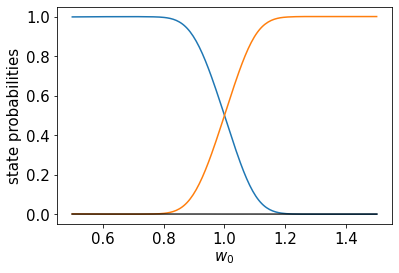

In [36]:
plt.plot(weight_diff_arr,probs_arr[:,2],label=r'$p_2$')
plt.plot(weight_diff_arr,probs_arr[:,1],label=r'$p_1$')
plt.plot(weight_diff_arr,probs_arr[:,0],color='k',alpha=0.5)
plt.plot(weight_diff_arr,probs_arr[:,3],color='k',alpha=0.5)
ax1=plt.gca()
plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel(r'$w_0$',fontsize=15)
plt.ylabel('state probabilities',fontsize=15)
plt.savefig('figures/wmis_swap.pdf',bbox_inches='tight')
plt.show()

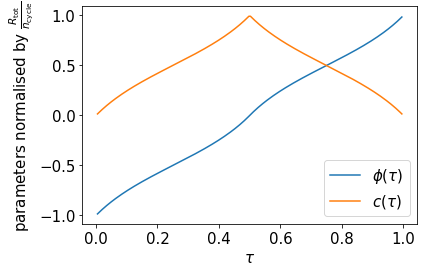

In [37]:
(phi_arr200,c_arr200)=cc.optimal_phase_and_disp_schedule_norm(200,rotation_per_stage=1)
plt.plot(np.linspace(1/201,200/201,200),phi_arr200,label=r'$\phi(\tau)$')
plt.plot(np.linspace(1/201,200/201,200),c_arr200,label=r'$c(\tau)$')
ax1=plt.gca()
plt.sca(ax1)
ax1.tick_params(labelsize=15)
plt.xlabel(r'$\tau$',fontsize=15)
plt.ylabel(r'parameters normalised by $\frac{R_\mathrm{tot}}{n_\mathrm{cycle}}$',fontsize=15)
plt.legend(fontsize=15)
plt.savefig('figures/anneal_protocol.pdf',bbox_inches='tight')
plt.show()

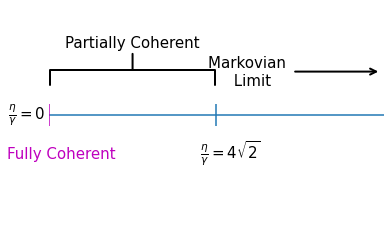

In [38]:
# set up the figure
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_xlim(0,10)
ax.set_ylim(0,10)

# draw lines
xmin = 0
xmax = 10
y = 5
height = 1

plt.hlines(y, xmin, xmax)
plt.vlines(xmin, y - height / 2., y + height / 2.,color='m')
plt.vlines(5, y - height / 2., y + height / 2.)

ax.annotate('Partially Coherent', xy=(0.25, 0.7), xytext=(0.25, 0.8), xycoords='axes fraction', 
            fontsize=15, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=5.5, lengthB=1', lw=2, color='k'))

ax.annotate('Markovian \n Limit', xy=(0.99, 0.7), xytext=(0.6, 0.7), xycoords='axes fraction', 
            fontsize=15, ha='center', va='center',
            arrowprops=dict(arrowstyle='->', lw=2, color='k'))

plt.text(xmin - 0.1, y-0.2, r'$\frac{\eta}{\gamma}=0$', horizontalalignment='right',fontsize=15)
plt.text(xmin + 2, y-2*height,'Fully Coherent', horizontalalignment='right',fontsize=15,color='m')
plt.text(xmax/2-0.5, y-2*height, r'$\frac{\eta}{\gamma}=4\sqrt{2}$',fontsize=15)
plt.axis('off')
plt.savefig('figures/regime_cartoon.pdf',bbox_inches='tight')
plt.show()

1571.5864720344543


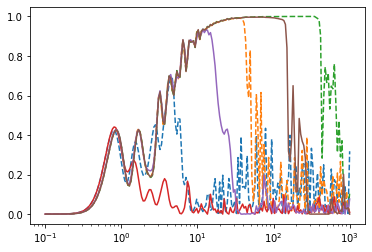

In [39]:
Op_drive=np.array([[0,1],[1,0]])
MIS_adj=np.zeros([5,5]) 
MIS_adj[0,1]=1
MIS_adj[0,2]=1
MIS_adj[1,2]=1
MIS_adj[1,4]=1
MIS_adj[2,3]=1
MIS_adj[2,4]=1
num_angle=200
tot_angle_arr=np.logspace(-1+np.log10(np.pi),3+np.log10(np.pi),num_angle)
num_cycle_list=[10,100,1000]
probs_arr_ideal=np.zeros([num_angle,len(num_cycle_list)])
probs_arr_phase=np.zeros([num_angle,len(num_cycle_list)])
start_time=time.time()
for i_num_cycle in range(len(num_cycle_list)):
    num_cycle=num_cycle_list[i_num_cycle]
    (phase_sched,driving_sched)=cc.optimal_phase_and_disp_schedule_norm(num_cycle)
    for i_angle in range(len(tot_angle_arr)):
        tot_angle=tot_angle_arr[i_angle]
        phase_schedule=(tot_angle/num_cycle)*phase_sched
        driving_schedule=(tot_angle/num_cycle)*driving_sched
        (psi_f,empty)=cc.idealised_state_vector_anneal_wmis(Op_drive,phase_schedule,MIS_adj,driving='ideal',driving_schedule=driving_schedule)
        probs_arr_ideal[i_angle,i_num_cycle]=np.abs(psi_f[25]**2)
        (psi_f,empty)=cc.idealised_state_vector_anneal_wmis(Op_drive,phase_schedule,MIS_adj,driving='before',driving_schedule=driving_schedule,interaction_Op=cc.MIS_apply_phase(phi=np.pi/2))
        probs_arr_phase[i_angle,i_num_cycle]=np.abs(psi_f[25]**2)
etime=time.time()-start_time
print(etime)
plt.semilogx(tot_angle_arr/np.pi,probs_arr_ideal,'--')
plt.semilogx(tot_angle_arr/np.pi,probs_arr_phase)

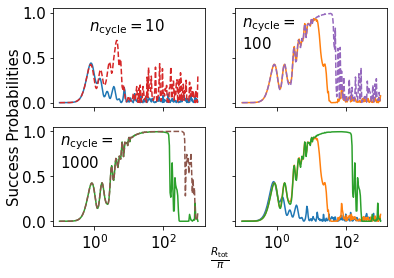

In [40]:
(fig, axs)=plt.subplots(2,2,sharey=True,sharex=True)
ax0=plt.subplot(2,2,1)
ax0.semilogx(tot_angle_arr/np.pi,probs_arr_phase[:,0],color=colors[0])
ax0.semilogx(tot_angle_arr/np.pi,probs_arr_ideal[:,0],'--',color=colors[3])
ax0.tick_params(labelsize=15)
ax0.text(0.7,0.8,r'$n_\mathrm{cycle}=10$',fontsize=15)
plt.ylabel('Success Probabilities',fontsize=15)
axs[0,0].yaxis.set_label_coords(-0.2,-0.2) # needs to be after the label is added
ax1=plt.subplot(2,2,2)
ax1.semilogx(tot_angle_arr/np.pi,probs_arr_phase[:,1],color=colors[1])
ax1.semilogx(tot_angle_arr/np.pi,probs_arr_ideal[:,1],'--',color=colors[4])
ax1.text(0.1,0.6,'$n_\mathrm{cycle}=$\n$100$',fontsize=15)
ax2=plt.subplot(2,2,3)
ax2.semilogx(tot_angle_arr/np.pi,probs_arr_phase[:,2],color=colors[2])
ax2.semilogx(tot_angle_arr/np.pi,probs_arr_ideal[:,2],'--',color=colors[5])
ax2.tick_params(labelsize=15)
ax2.text(0.1,0.6,'$n_\mathrm{cycle}=$\n$1000$',fontsize=15)
ax3=plt.subplot(2,2,4)
ax3.semilogx(tot_angle_arr/np.pi,probs_arr_phase)
ax3.tick_params(labelsize=15)
plt.xlabel(r'$\frac{R_\mathrm{tot}}{\pi}$',fontsize=15)
ax3.xaxis.set_label_coords(-0.1,-0.2)
plt.savefig('figures/ideal_vs_Zeno_5QB.pdf',bbox_inches='tight')
plt.show()